[2026-03-01 15:04:31] === Start AR demo on 1 random coin ===
[2026-03-01 15:04:31] Selected coin for AR: SOL (solana)
[2026-03-01 15:04:31] GET https://api.coingecko.com/api/v3/coins/solana/market_chart (attempt 1/3)
[2026-03-01 15:04:33] Fetched 2161 rows for SOL
[2026-03-01 15:04:33] Length of return series: 2160
[2026-03-01 15:04:33] Train size: 1728, Test size: 432
[2026-03-01 15:04:33] Fitting AR(5) model...
[2026-03-01 15:04:33] AR model fitted.

=== AR Coefficients (including intercept) ===
const    -0.000236
ret.L1    0.060692
ret.L2   -0.017088
ret.L3    0.038868
ret.L4    0.033844
ret.L5   -0.037949
dtype: float64
[2026-03-01 15:04:33] MSE = 6.552150e-05, RMSE = 8.094535e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


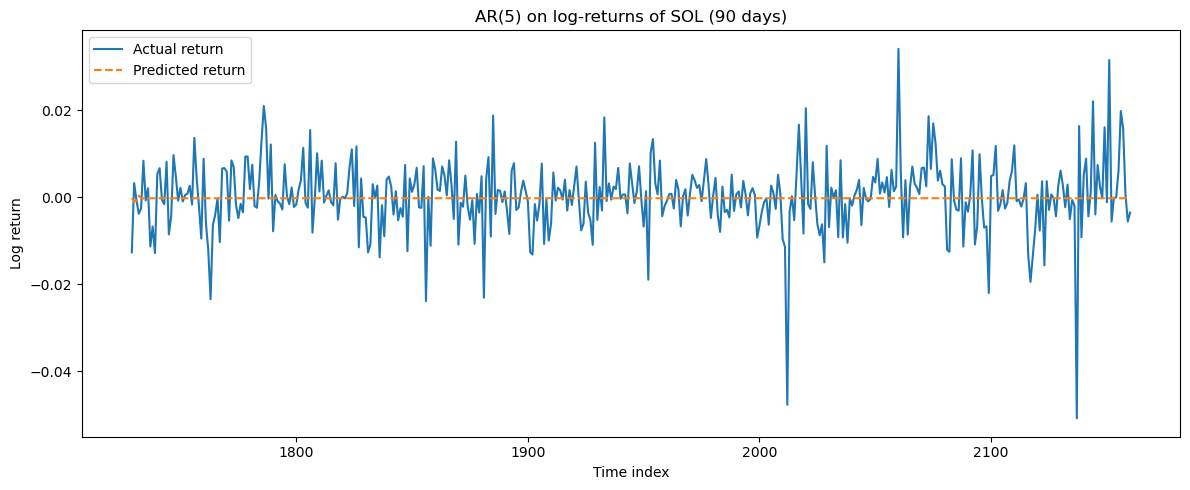

[2026-03-01 15:04:33] === Done ===


In [1]:
import time
import math
import random
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg

# ============================
# 設定
# ============================
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90

BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"
MAX_RETRIES = 3
SLEEP_ON_429 = 5
SLEEP_BETWEEN_CALLS = 3


# ============================
# ログ用
# ============================
def log(msg: str) -> None:
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{now}] {msg}")


# ============================
# API 取得関数
# ============================
session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (compatible; stable-demo/1.0)"
})


def fetch_market_chart(coin_id, days=90, vs="usd"):
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            log(f"GET {url} (attempt {attempt}/{MAX_RETRIES})")
            r = session.get(url, params=params, timeout=30)

            if r.status_code == 200:
                data = r.json()
                df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
                df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
                return df

            if r.status_code == 429:
                log(f"[429] Too Many Requests. Waiting {SLEEP_ON_429} sec...")
                time.sleep(SLEEP_ON_429)
                continue

            r.raise_for_status()

        except requests.RequestException as e:
            log(f"[ERROR] {e}. Waiting 3 sec and retry...")
            time.sleep(3)

    raise RuntimeError(f"Failed after {MAX_RETRIES} retries: {coin_id}")


# ============================
# AR モデルを適用する処理
# ============================
def apply_ar_to_random_coin():
    # 1. コインを1つランダムに選ぶ
    coin_id, symbol = random.choice(COINS_POOL)
    log(f"Selected coin for AR: {symbol} ({coin_id})")

    # 2. データ取得
    df = fetch_market_chart(coin_id, DAYS, VS)
    log(f"Fetched {len(df)} rows for {symbol}")

    # 3. 対数リターンの計算
    df = df.sort_values("timestamp")
    df["log_price"] = np.log(df["price"])
    df["ret"] = df["log_price"].diff()  # 対数リターン
    series = df["ret"].dropna()

    log(f"Length of return series: {len(series)}")

    # 4. 学習・テストに分割（例：80% / 20%）
    train_size = int(len(series) * 0.8)
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]

    log(f"Train size: {len(train)}, Test size: {len(test)}")

    # 5. AR(p) モデルを学習（ここでは p=5）
    LAGS = 5
    log(f"Fitting AR({LAGS}) model...")
    model = AutoReg(train, lags=LAGS, old_names=False)
    res = model.fit()
    log("AR model fitted.")

    # パラメータ表示
    print("\n=== AR Coefficients (including intercept) ===")
    print(res.params)

    # 6. テスト区間を予測
    start = train.index[-1]  # 直前のインデックス
    # AutoReg の predict は整数インデックスでも時間インデックスでも指定可能
    pred = res.predict(start=train_size, end=train_size + len(test) - 1, dynamic=False)

    # 7. シンプルな評価（MSE / RMSE）
    mse = ((test.values - pred.values) ** 2).mean()
    rmse = np.sqrt(mse)
    log(f"MSE = {mse:.6e}, RMSE = {rmse:.6e}")

    # 8. グラフ表示（実測 vs 予測）
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test.values, label="Actual return")
    plt.plot(test.index, pred.values, label="Predicted return", linestyle="--")
    plt.title(f"AR({LAGS}) on log-returns of {symbol} ({DAYS} days)")
    plt.xlabel("Time index")
    plt.ylabel("Log return")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "coin_id": coin_id,
        "symbol": symbol,
        "model": res,
        "mse": mse,
        "rmse": rmse,
    }


# ============================
# メイン
# ============================
if __name__ == "__main__":
    log("=== Start AR demo on 1 random coin ===")
    result = apply_ar_to_random_coin()
    log("=== Done ===")